<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment3_Multiple_Linear_Regression_using_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving multiple_linear_regression_dataset.csv to multiple_linear_regression_dataset (1).csv
Dataset shape: (20, 3)
   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830
Epoch: 0 Loss: 1867204563.0512133
Epoch: 100 Loss: 41815247.06548924
Epoch: 200 Loss: 4196772.8663056325
Epoch: 300 Loss: 1994045.0217270756
Epoch: 400 Loss: 1774667.1253028533
Epoch: 500 Loss: 1744846.6510198861
Epoch: 600 Loss: 1740338.2396749551
Epoch: 700 Loss: 1739637.5467215749
Epoch: 800 Loss: 1739527.9253415368
Epoch: 900 Loss: 1739510.7489502325

Model Evaluation
Mean Squared Error: 753660.6476300685
R2 Score: 0.9387208915791145


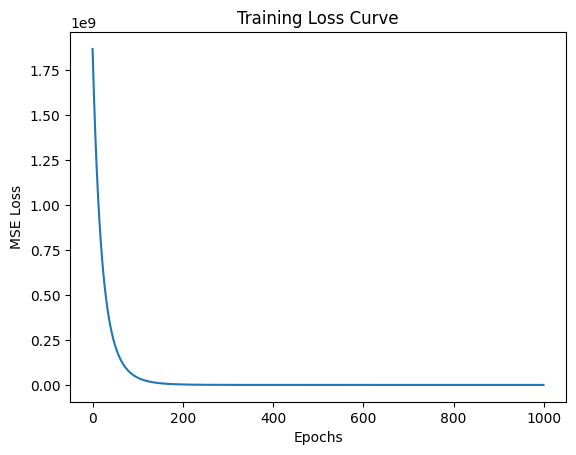

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


from google.colab import files
uploaded = files.upload()

data = pd.read_csv("multiple_linear_regression_dataset.csv")

print("Dataset shape:", data.shape)
print(data.head())


X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


y = y.reshape(-1,1)


scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


n_features = X_train.shape[1]

np.random.seed(42)

W = np.random.randn(n_features,1) * 0.01
b = np.zeros((1,1))



def forward(X,W,b):

    y_pred = np.dot(X,W) + b
    return y_pred



def compute_loss(y, y_pred):

    loss = np.mean((y - y_pred)**2)
    return loss


learning_rate = 0.01
epochs = 1000

losses = []

for i in range(epochs):

    y_pred = forward(X_train,W,b)

    loss = compute_loss(y_train,y_pred)
    losses.append(loss)

    dW = (-2/X_train.shape[0]) * np.dot(X_train.T,(y_train - y_pred))
    db = (-2/X_train.shape[0]) * np.sum(y_train - y_pred)

    W -= learning_rate * dW
    b -= learning_rate * db

    if i % 100 == 0:
        print("Epoch:",i,"Loss:",loss)



y_pred_test = forward(X_test,W,b)


mse = mean_squared_error(y_test,y_pred_test)
r2 = r2_score(y_test,y_pred_test)

print("\nModel Evaluation")
print("Mean Squared Error:",mse)
print("R2 Score:",r2)


plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()